In [245]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
import os
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix

pd.set_option('display.max_rows', None)

In [246]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','planning')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [247]:
input_dir = os.path.join('..', 'pre-processed', 'data_for_fMRI_modelling')
data = pd.read_csv(os.path.join(input_dir, 'combined_dataframe_binary.csv'), sep= ';')
data = data.sort_values(by=['trial'], ascending=[True])
data = data.reset_index(drop=True)
print(data)

     index  trial  emotional_cue_time response  objectively_correct  subjectively_correct  response_time   RT_s  stimuli_type  iti  ...  stimuli_name  reward_amount subject_id  session  congruency  \
0        0      8        1.720101e+09       up                 True                  True   1.720101e+09  0.447             2    3  ...     Angry_b33           -0.3        902        3           1   
1      312      9        1.720101e+09       up                False                  True   1.720101e+09  0.376             1    2  ...     Happy_b25           -0.2        902        3           1   
2      313     10        1.720101e+09     down                 True                  True   1.720101e+09  0.405             1    2  ...     Happy_b16           -0.1        902        3           1   
3        1     11        1.720101e+09     down                False                  True   1.720101e+09  0.377             2    2  ...      Angry_b3            0.0        902        3           1   


# Vary the ITI

In [248]:
# Now set ITI etc
trial_number =len(data)
median_iti = 7
simulate_iti = True

generated_onset=[0]
for i in range(1, trial_number):
    generated_onset.append(generated_onset[i-1] + random.uniform(median_iti - 1, median_iti + 1))

if simulate_iti is True:
    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]
    data['emotional_cue_time_original'] = data['emotional_cue_time']
    data['emotional_cue_time'] = generated_onset
    print(data[['emotional_cue_time','emotional_cue_time_original','valence']])
else:
    data['emotional_cue_time'] = data['emotional_cue_time'] - data['emotional_cue_time'][0]
    print(data[['emotional_cue_time','valence']])
    print(f'average iti ')

     emotional_cue_time  emotional_cue_time_original  valence
0              0.000000                     0.000000        0
1              6.248233                     5.331079        1
2             13.318216                     9.676697        1
3             19.425877                    14.023166        0
4             27.128480                    18.366102        0
5             33.694842                    23.711322        1
6             41.297429                    28.047139        1
7             48.744391                    33.390892        0
8             55.060308                    37.725442        0
9             61.733512                    42.058177        0
10            68.989280                    47.436675        1
11            76.305274                    51.786124        1
12            82.834706                    56.127810        1
13            89.811604                    61.468858        0
14            97.108953                    65.812464        0
15      

# Quickly recode into something the design matrix can use

In [249]:
data['valence'] = data['valence'].replace({0:'angry', 1:'happy'})
data['congruency'] = data['congruency'].replace({0:'incongruent', 1:'congruent'})
data['volatility'] = data['volatility'].replace({0:'stable', 1:'volatile'})
data['onset'] = data['emotional_cue_time']
data['duration'] = 0.1
print(data[['valence','congruency','volatility','onset','duration']])

    valence   congruency volatility        onset  duration
0     angry    congruent     stable     0.000000       0.1
1     happy    congruent     stable     6.248233       0.1
2     happy    congruent     stable    13.318216       0.1
3     angry    congruent     stable    19.425877       0.1
4     angry    congruent     stable    27.128480       0.1
5     happy    congruent     stable    33.694842       0.1
6     happy    congruent     stable    41.297429       0.1
7     angry    congruent     stable    48.744391       0.1
8     angry    congruent     stable    55.060308       0.1
9     angry    congruent     stable    61.733512       0.1
10    happy    congruent     stable    68.989280       0.1
11    happy    congruent     stable    76.305274       0.1
12    happy    congruent     stable    82.834706       0.1
13    angry    congruent     stable    89.811604       0.1
14    angry    congruent     stable    97.108953       0.1
15    happy    congruent     stable   103.184896       0

In [250]:
# Create the new dataframe by transforming the data
restructured_rows = []
for _, row in data.iterrows():
    restructured_rows.append({'trial_type': row['valence'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['volatility'], 'onset': row['onset'], 'duration': row['duration']})

# Convert to dataframe
data_design_matrix = pd.DataFrame(restructured_rows)

print(data_design_matrix)

       trial_type        onset  duration
0           angry     0.000000       0.1
1       congruent     0.000000       0.1
2          stable     0.000000       0.1
3           happy     6.248233       0.1
4       congruent     6.248233       0.1
5          stable     6.248233       0.1
6           happy    13.318216       0.1
7       congruent    13.318216       0.1
8          stable    13.318216       0.1
9           angry    19.425877       0.1
10      congruent    19.425877       0.1
11         stable    19.425877       0.1
12          angry    27.128480       0.1
13      congruent    27.128480       0.1
14         stable    27.128480       0.1
15          happy    33.694842       0.1
16      congruent    33.694842       0.1
17         stable    33.694842       0.1
18          happy    41.297429       0.1
19      congruent    41.297429       0.1
20         stable    41.297429       0.1
21          angry    48.744391       0.1
22      congruent    48.744391       0.1
23         stabl

# Scanner info

In [251]:
# Repetition time
tr = 1

# Define scan volumes
time_length = math.ceil(max(data_design_matrix['onset']))
n_volumes = np.linspace(0, time_length, (tr * time_length + 1))
total_volumes = len(n_volumes)

# Design matrix

In [252]:
plot_name = 'Design matrix'
events = pd.DataFrame(
    {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
)
print(events)

       trial_type        onset  duration
0           angry     0.000000       0.1
1       congruent     0.000000       0.1
2          stable     0.000000       0.1
3           happy     6.248233       0.1
4       congruent     6.248233       0.1
5          stable     6.248233       0.1
6           happy    13.318216       0.1
7       congruent    13.318216       0.1
8          stable    13.318216       0.1
9           angry    19.425877       0.1
10      congruent    19.425877       0.1
11         stable    19.425877       0.1
12          angry    27.128480       0.1
13      congruent    27.128480       0.1
14         stable    27.128480       0.1
15          happy    33.694842       0.1
16      congruent    33.694842       0.1
17         stable    33.694842       0.1
18          happy    41.297429       0.1
19      congruent    41.297429       0.1
20         stable    41.297429       0.1
21          angry    48.744391       0.1
22      congruent    48.744391       0.1
23         stabl

In [253]:
design_matrix = make_first_level_design_matrix(
    n_volumes,
    data_design_matrix,
    drift_model = None
)
design_matrix = design_matrix[['angry','happy','congruent','incongruent','stable','volatile','constant']]
print(design_matrix)

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


               angry         happy     congruent   incongruent        stable      volatile  constant
0.0    -3.192910e-14 -3.212119e-14  1.357830e-14  1.287500e-14  1.659799e-14  1.653863e-14       1.0
1.0     1.999409e-04 -1.898254e-14  1.999409e-04  2.159530e-14  1.999409e-04 -5.637049e-15       1.0
2.0     3.966518e-03  4.170692e-15  3.966518e-03  1.903024e-14  3.966518e-03 -2.560331e-14       1.0
3.0     1.374693e-02 -3.128998e-17  1.374693e-02  7.133949e-16  1.374693e-02 -2.371305e-15       1.0
4.0     2.371122e-02 -3.748029e-15  2.371122e-02 -1.140904e-14  2.371122e-02  1.428935e-14       1.0
5.0     2.787399e-02 -2.225005e-16  2.787399e-02 -4.222654e-16  2.787399e-02 -4.323132e-18       1.0
6.0     2.540001e-02 -1.066364e-16  2.540001e-02 -7.110048e-16  2.540001e-02 -9.981858e-18       1.0
7.0     1.882239e-02  4.299526e-05  1.886538e-02 -3.429145e-16  1.886538e-02 -7.271377e-16       1.0
8.0     1.112252e-02  2.344590e-03  1.346711e-02 -9.305018e-16  1.346711e-02 -2.726654e-16 

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5769/3954100264.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


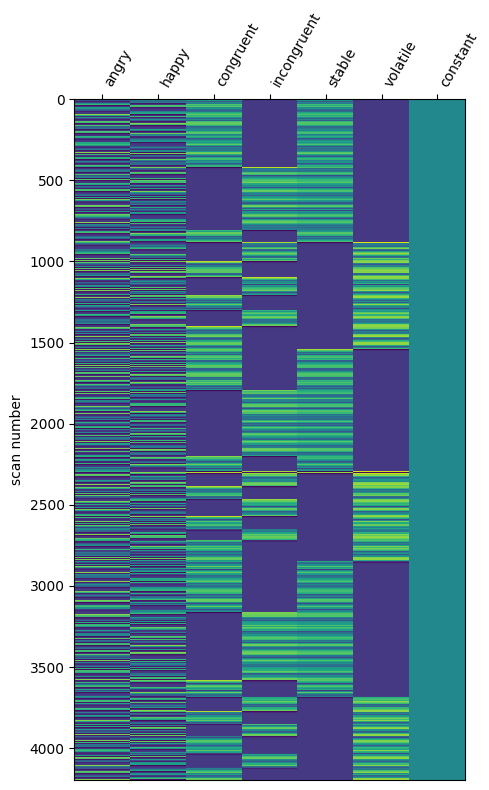

In [254]:
fig, ax = plt.subplots(figsize=(5, 8), nrows=1, ncols=1)
plot_design_matrix(design_matrix, ax=ax)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
fig.show()

In [255]:
pd.set_option('display.width', 200)
print(design_matrix.corr())

                angry     happy  congruent  incongruent    stable  volatile  constant
angry        1.000000 -0.829729   0.100097     0.110394  0.131697  0.084391 -0.368907
happy       -0.829729  1.000000   0.117372     0.097953  0.120611  0.101268  0.358182
congruent    0.100097  0.117372   1.000000    -0.733757  0.169944  0.109312 -0.102733
incongruent  0.110394  0.097953  -0.733757     1.000000  0.145470  0.122921  0.090940
stable       0.131697  0.120611   0.169944     0.145470  1.000000 -0.717291 -0.227199
volatile     0.084391  0.101268   0.109312     0.122921 -0.717291  1.000000  0.225706
constant    -0.368907  0.358182  -0.102733     0.090940 -0.227199  0.225706  1.000000


# Raw HRF

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5769/4059402365.py:7: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  design_matrix_hrf_plot = design_matrix[:length]


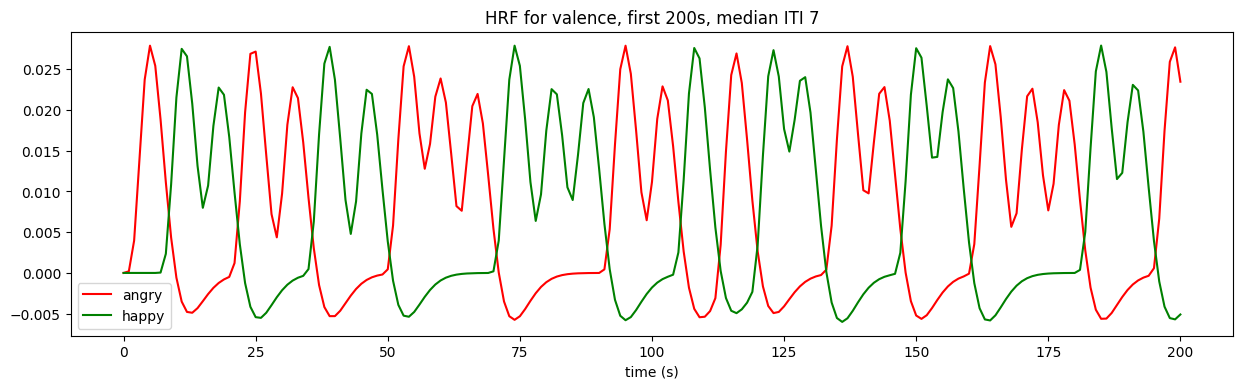

In [256]:
plot_name = f'HRF for valence, first 200s, median ITI {median_iti}'
length = 200

fig = plt.figure(figsize=(15, 4))

n_volumes_selection = n_volumes[:length+1]
design_matrix_hrf_plot = design_matrix[:length]
design_matrix_hrf_plot = design_matrix_hrf_plot.drop(columns=['congruent', 'incongruent', 'stable', 'volatile', 'constant'])

plt.plot(design_matrix_hrf_plot['angry'], label='angry', color='r')
plt.plot(design_matrix_hrf_plot['happy'], label='happy', color='g')
plt.xlabel("time (s)")
plt.legend()
plt.title(plot_name)

# adjust plot
plt.subplots_adjust(bottom=0.12)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()